In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [18]:
df = pd.read_csv(r"C:\Users\HP\Downloads\Train.csv")
df.head()

,ID,timestamp,precipitation (mm),radiation (W/m2),relativehumidity (-),temperature (degrees Celsius),station,station_name,country,installation_height,elevation,latitude,longitude
0,cd7ebf43_2018-01_VAH5X7,1/20/2018 8:15,0.0,224,0.319,17.3,TA00349,Lycee De Mopti,ML,2.0,271.0,14.49461,-4.188941
1,cd7ebf43_2018-01_YWVE4N,1/20/2018 8:30,0.0,272,0.309,18.0,TA00349,Lycee De Mopti,ML,2.0,271.0,14.49461,-4.188941
2,cd7ebf43_2018-01_1UZFA5,1/20/2018 8:45,0.0,328,0.303,18.9,TA00349,Lycee De Mopti,ML,2.0,271.0,14.49461,-4.188941
3,cd7ebf43_2018-01_QJQJ5C,1/20/2018 9:00,0.0,272,0.265,20.0,TA00349,Lycee De Mopti,ML,2.0,271.0,14.49461,-4.188941
4,cd7ebf43_2018-01_ST8VGF,1/20/2018 9:15,0.0,283,0.240,21.1,TA00349,Lycee De Mopti,ML,2.0,271.0,14.49461,-4.188941


In [19]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 642175 entries, 0 to 642174
Data columns (total 13 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   ID                             642175 non-null  str    
 1   timestamp                      642175 non-null  str    
 2   precipitation (mm)             642175 non-null  float64
 3   radiation (W/m2)               642175 non-null  int64  
 4   relativehumidity (-)           642175 non-null  float64
 5   temperature (degrees Celsius)  642175 non-null  float64
 6   station                        642175 non-null  str    
 7   station_name                   642175 non-null  str    
 8   country                        642175 non-null  str    
 9   installation_height            642175 non-null  float64
 10  elevation                      642175 non-null  float64
 11  latitude                       642175 non-null  float64
 12  longitude                      642175 non

In [20]:
df.duplicated().sum()

np.int64(0)

In [21]:
df["country"].unique()

<ArrowStringArray>
['ML', 'KE', 'GH', 'MW', 'UG', 'NG', 'BJ']
Length: 7, dtype: str

In [24]:
df['timestamp'] = pd.to_datetime(df['timestamp'])

In [25]:
df['hour'] = df['timestamp'].dt.hour
df['minute'] = df['timestamp'].dt.minute
df['month'] = df['timestamp'].dt.month
df['day_of_year'] = df['timestamp'].dt.dayofyear

In [26]:
df['radiation (W/m2)'].describe()

count    642175.000000
mean        190.367792
std         281.677984
min           0.000000
25%           0.000000
50%           0.000000
75%         333.000000
max        1427.000000
Name: radiation (W/m2), dtype: float64

In [27]:
df['radiation (W/m2)'].value_counts().head()

radiation (W/m2)
0    322869
1      3540
2      2702
3      2064
5      1844
Name: count, dtype: int64

In [28]:
df.groupby('hour')['radiation (W/m2)'].agg(['count', 'mean', 'min', 'max'])

,count,mean,min,max
hour,,,,
0,26673,0.911034,0,200
1,26656,0.911014,0,200
2,26652,0.945370,0,222
3,26637,2.798363,0,216
4,26642,29.687111,0,403
5,26632,90.225593,0,727
6,26650,171.554559,0,916
7,26666,284.285082,0,1096
8,26703,411.010224,0,1329


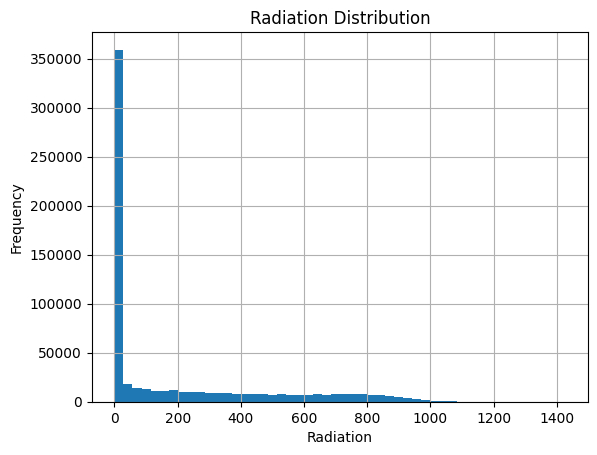

In [30]:
df['radiation (W/m2)'].hist(bins=50)
plt.xlabel('Radiation')
plt.ylabel('Frequency')
plt.title('Radiation Distribution')
plt.show()

In [31]:
df[['radiation (W/m2)',
    'temperature (degrees Celsius)',
    'relativehumidity (-)',
    'precipitation (mm)']].corr()

,radiation (W/m2),temperature (degrees Celsius),relativehumidity (-),precipitation (mm)
radiation (W/m2),1.000000,0.443269,-0.324471,-0.011027
temperature (degrees Celsius),0.443269,1.000000,-0.581012,0.001288
relativehumidity (-),-0.324471,-0.581012,1.000000,0.014276
precipitation (mm),-0.011027,0.001288,0.014276,1.000000


<Axes: >

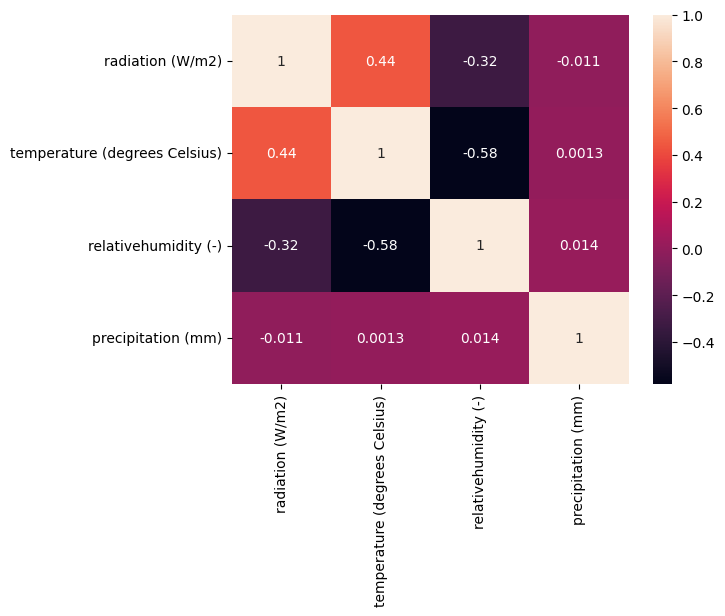

In [34]:
sns.heatmap(df[['radiation (W/m2)',
                    'temperature (degrees Celsius)',
                    'relativehumidity (-)',
                    'precipitation (mm)']].corr(), annot=True)

In [35]:
df['station'].unique()

<ArrowStringArray>
['TA00349', 'TA00354', 'TA00344', 'TA00374', 'TA00121', 'TA00360', 'TA00365',
 'TA00335', 'TA00353', 'TA00078', 'TA00358', 'TA00122', 'TA00359', 'TA00697',
 'TA00117', 'TA00343', 'TA00134', 'TA00338', 'TA00346', 'TA00328', 'TA00109',
 'TA00325', 'TA00336', 'TA00331', 'TA00330', 'TA00350', 'TA00337', 'TA00119',
 'TA00587', 'TA00118', 'TA00692', 'TA00333', 'TA00361', 'TA00342', 'TA00123',
 'TA00348', 'TA00355', 'TA00696', 'TA00334', 'TA00375']
Length: 40, dtype: str

In [36]:
df['station'].value_counts()

station
TA00330    17437
TA00587    17416
TA00325    17344
TA00333    17109
TA00331    17094
TA00328    17013
TA00338    16939
TA00337    16833
TA00336    16739
TA00109    16712
TA00078    16658
TA00335    16643
TA00692    16620
TA00334    16559
TA00119    16460
TA00122    16257
TA00343    16237
TA00123    16223
TA00355    16171
TA00344    16155
TA00697    16084
TA00346    16076
TA00121    16004
TA00360    16000
TA00348    15995
TA00349    15807
TA00342    15791
TA00354    15648
TA00358    15614
TA00359    15517
TA00353    15492
TA00350    15407
TA00374    15400
TA00375    15313
TA00134    15208
TA00696    15196
TA00117    15194
TA00361    15102
TA00365    14995
TA00118    11713
Name: count, dtype: int64

In [37]:
df.groupby('station')['radiation (W/m2)'].agg(
    ['count', 'mean', 'min', 'max']
).sort_values('mean', ascending=False)

,count,mean,min,max
station,,,,
TA00355,16171,259.248902,0,1103
TA00348,15995,255.699469,0,1169
TA00359,15517,230.768576,0,1177
TA00354,15648,230.560455,0,1118
TA00346,16076,226.249565,0,1145
TA00344,16155,221.093717,0,1052
TA00334,16559,216.146386,0,1316
TA00375,15313,211.233396,0,1427
TA00365,14995,210.730577,0,1224


In [38]:
df[df['station'] == 'TA00338']['radiation (W/m2)'].describe()

count    16939.000000
mean        25.963457
std        117.629618
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max       1221.000000
Name: radiation (W/m2), dtype: float64

In [39]:
df[df['station'] == 'TA00338'].groupby('hour')['radiation (W/m2)'].mean()

hour
0      0.000000
1      0.000000
2      0.000000
3      0.000000
4      0.000000
5      0.000000
6      0.528409
7      8.467330
8     28.437500
9     58.149148
10    76.745739
11    88.495739
12    90.933239
13    82.384724
14    71.492938
15    55.733051
16    40.201977
17    18.638418
18     3.074859
19     0.000000
20     0.000000
21     0.000000
22     0.000000
23     0.000000
Name: radiation (W/m2), dtype: float64

In [40]:
df[df['station'] == 'TA00355'].groupby('hour')['radiation (W/m2)'].mean()

hour
0       0.000000
1       0.000000
2       0.000000
3       4.944940
4      95.395833
5     276.441964
6     491.680060
7     674.302083
8     805.343750
9     880.587798
10    872.354167
11    792.138393
12    638.979167
13    440.208580
14    219.062130
15     42.902367
16      0.041420
17      0.000000
18      0.000000
19      0.000000
20      0.000000
21      0.000000
22      0.000000
23      0.000000
Name: radiation (W/m2), dtype: float64

In [41]:
df['timestamp'].diff().value_counts()

timestamp
0 days 00:15:00        641726
31 days 00:15:00           78
30 days 00:15:00           77
0 days 00:30:00            63
0 days 00:45:00            38
                        ...  
48 days 09:30:00            1
-319 days +13:15:00         1
56 days 17:15:00            1
-688 days +12:30:00         1
-310 days +12:00:00         1
Name: count, Length: 76, dtype: int64

In [42]:
df = df.sort_values('timestamp').reset_index(drop=True)

In [43]:
gaps = df['timestamp'].diff()

In [44]:
gaps.value_counts().head(10)

timestamp
0 days 00:00:00     557251
0 days 00:15:00      84885
30 days 00:15:00        10
31 days 00:15:00        10
0 days 00:30:00          8
28 days 00:15:00         3
29 days 00:15:00         2
40 days 16:30:00         1
33 days 00:15:00         1
33 days 11:30:00         1
Name: count, dtype: int64

In [45]:
gaps[gaps != pd.Timedelta(minutes=15)].value_counts().head(20)

timestamp
0 days 00:00:00     557251
30 days 00:15:00        10
31 days 00:15:00        10
0 days 00:30:00          8
28 days 00:15:00         3
29 days 00:15:00         2
40 days 16:30:00         1
33 days 00:15:00         1
33 days 11:30:00         1
41 days 16:30:00         1
0 days 01:00:00          1
Name: count, dtype: int64

In [46]:
df.loc[
    gaps != pd.Timedelta(minutes=15),
    ['timestamp', 'station']
].head(20)

,timestamp,station
0,2016-01-11 10:30:00,TA00078
1974,2016-03-01 00:00:00,TA00078
4950,2016-05-01 00:00:00,TA00078
5460,2016-05-06 07:45:00,TA00078
7371,2016-05-26 05:45:00,TA00078
7890,2016-05-31 15:45:00,TA00078
7923,2016-07-01 00:00:00,TA00078
10899,2016-09-01 00:00:00,TA00078
13779,2016-11-01 00:00:00,TA00078
15337,2016-11-17 05:45:00,TA00078


In [47]:
df = df.sort_values(['station', 'timestamp'])

gaps = df.groupby('station')['timestamp'].diff()

gaps.value_counts().head(20)

timestamp
0 days 00:15:00     641726
31 days 00:15:00        78
30 days 00:15:00        77
0 days 00:30:00         63
0 days 00:45:00         38
28 days 00:15:00        36
0 days 01:15:00         30
0 days 01:00:00         24
0 days 01:30:00         16
0 days 01:45:00          6
0 days 06:15:00          4
29 days 00:15:00         3
0 days 02:30:00          3
0 days 05:15:00          3
0 days 05:00:00          3
0 days 02:00:00          3
0 days 02:45:00          2
94 days 12:45:00         1
0 days 03:30:00          1
0 days 02:15:00          1
Name: count, dtype: int64

In [48]:
gaps[gaps > pd.Timedelta(minutes=15)].value_counts().head(20)

timestamp
31 days 00:15:00    78
30 days 00:15:00    77
0 days 00:30:00     63
0 days 00:45:00     38
28 days 00:15:00    36
0 days 01:15:00     30
0 days 01:00:00     24
0 days 01:30:00     16
0 days 01:45:00      6
0 days 06:15:00      4
29 days 00:15:00     3
0 days 02:30:00      3
0 days 05:15:00      3
0 days 05:00:00      3
0 days 02:00:00      3
0 days 02:45:00      2
94 days 12:45:00     1
0 days 03:30:00      1
0 days 02:15:00      1
0 days 04:30:00      1
Name: count, dtype: int64

In [49]:
df['gap'] = df.groupby('station')['timestamp'].diff()

df[df['gap'] > pd.Timedelta(minutes=15)][
    ['station', 'timestamp', 'gap']
].head(30)

,station,timestamp,gap
1974,TA00078,2016-03-01 00:00:00,29 days 00:15:00
4950,TA00078,2016-05-01 00:00:00,30 days 00:15:00
5460,TA00078,2016-05-06 07:45:00,0 days 00:30:00
7371,TA00078,2016-05-26 05:45:00,0 days 00:30:00
7890,TA00078,2016-05-31 15:45:00,0 days 00:30:00
7923,TA00078,2016-07-01 00:00:00,30 days 00:15:00
10899,TA00078,2016-09-01 00:00:00,31 days 00:15:00
13779,TA00078,2016-11-01 00:00:00,31 days 00:15:00
15337,TA00078,2016-11-17 05:45:00,0 days 00:30:00
26328,TA00109,2017-03-01 00:00:00,28 days 00:15:00


In [50]:
df['gap'] = df.groupby('station')['timestamp'].diff()

missing_intervals = df[
    (df['gap'] > pd.Timedelta(minutes=15)) &
    (df['timestamp'].dt.month % 2 == 1)
]

missing_intervals[['station', 'timestamp', 'gap']].head(20)

,station,timestamp,gap
1974,TA00078,2016-03-01 00:00:00,29 days 00:15:00
4950,TA00078,2016-05-01 00:00:00,30 days 00:15:00
5460,TA00078,2016-05-06 07:45:00,0 days 00:30:00
7371,TA00078,2016-05-26 05:45:00,0 days 00:30:00
7890,TA00078,2016-05-31 15:45:00,0 days 00:30:00
7923,TA00078,2016-07-01 00:00:00,30 days 00:15:00
10899,TA00078,2016-09-01 00:00:00,31 days 00:15:00
13779,TA00078,2016-11-01 00:00:00,31 days 00:15:00
15337,TA00078,2016-11-17 05:45:00,0 days 00:30:00
26328,TA00109,2017-03-01 00:00:00,28 days 00:15:00


In [51]:
missing_intervals.shape

(409, 18)

In [52]:
df[df['gap'] > pd.Timedelta(minutes=15)][
    ['station', 'timestamp', 'gap']
].head(30)

,station,timestamp,gap
1974,TA00078,2016-03-01 00:00:00,29 days 00:15:00
4950,TA00078,2016-05-01 00:00:00,30 days 00:15:00
5460,TA00078,2016-05-06 07:45:00,0 days 00:30:00
7371,TA00078,2016-05-26 05:45:00,0 days 00:30:00
7890,TA00078,2016-05-31 15:45:00,0 days 00:30:00
7923,TA00078,2016-07-01 00:00:00,30 days 00:15:00
10899,TA00078,2016-09-01 00:00:00,31 days 00:15:00
13779,TA00078,2016-11-01 00:00:00,31 days 00:15:00
15337,TA00078,2016-11-17 05:45:00,0 days 00:30:00
26328,TA00109,2017-03-01 00:00:00,28 days 00:15:00


In [53]:
df[df['gap'] > pd.Timedelta(minutes=15)]['gap'].value_counts().head(20)

gap
31 days 00:15:00    78
30 days 00:15:00    77
0 days 00:30:00     63
0 days 00:45:00     38
28 days 00:15:00    36
0 days 01:15:00     30
0 days 01:00:00     24
0 days 01:30:00     16
0 days 01:45:00      6
0 days 06:15:00      4
29 days 00:15:00     3
0 days 02:30:00      3
0 days 05:15:00      3
0 days 05:00:00      3
0 days 02:00:00      3
0 days 02:45:00      2
94 days 12:45:00     1
0 days 03:30:00      1
0 days 02:15:00      1
0 days 04:30:00      1
Name: count, dtype: int64

In [54]:
df.groupby(df['timestamp'].dt.month)['radiation (W/m2)'].count()

timestamp
1      58877
3     116045
5     119036
7     118297
9     114839
11    115081
Name: radiation (W/m2), dtype: int64